# Problem 014

https://projecteuler.net/problem=14


## Initial thoughts/brute force approach

Very cool problem. From what I can tell, the problem was listed on PE back in 2002, and the conjecture is still unsolved. 

My supervisor for Part II Number Theory commented on it a few times back in '24. Much love to Mansur Boase.

Initial thoughts may be to just take every integer from $1-1,000,000$ and then compute the length of the Collatz sequence from there. But this is incredibly inefficient: for the example give, we would need to compute the lengths of the chain for $13, 40, 20, 10$ all independently. 


## Improved solution

If we want to instead reuse previous computations, what we can do is a **dynamic programming(DP)** approach, more specifically memoisation. 

Going back to our previous example, if we have already computed the chain length starting from $40$, we should not recompute it every time another starting value eventually reaches $40$.

Let $L(n)$ be the length of the Collatz chain starting from $n$. Then

$$
L(n) = 1 + L(T(n)),
$$

where

$$
T(n) =
\begin{cases}
n/2, & n \text{ even}, \\
3n + 1, & n \text{ odd}.
\end{cases}
$$

The base case is

$$
L(1) = 1.
$$

Memoisation means storing already-computed values of $L(n)$ in a dictionary. Then, when a new chain reaches a value whose length we already know, we can stop and fill in the missing lengths backwards.

In [12]:
def referTo(num1:int) -> int :
    if num1 % 2 == 0:
        return num1//2
    return (3*num1 + 1)

In [13]:
# A first thought might be to make a list of length 3_000_000,
# since one odd step from below 1_000_000 is below 3_000_001.
# But this is not a real upper bound on the whole sequence, so a
# dictionary is safer.
def collatzLength(num:int, knownLengths: dict[int, int]) -> int:
    path = []
    currentNum = num

    while currentNum not in knownLengths:
        path.append(currentNum)
        currentNum = referTo(currentNum)
    
    length = knownLengths[currentNum]

    for value in reversed(path):
        length += 1
        knownLengths[value] = length

    return knownLengths[num]

## A New Data Structure?

One important detail is that although the starting values are below one million, the Collatz sequence itself does not have to stay below one million.

For example, an odd value is sent to

$$3n + 1$$

which can immediately jump above the original search limit. So even if we only test starting numbers below 1_000_000, the intermediate values can be much larger.

This is why I use a dictionary (storing data in terms of 'keys' and 'values') rather than a fixed-size list. 

A list indexed up to 1_000_000 would only naturally store values below the original limit, while a dictionary can store chain lengths for any intermediate value we encounter, including values above one million. Additionally, dictionary lookup and insertion both happen within constant time. I do not need to set up a list of length 3_000_000. 

In my own testing, some chains quickly reached values well above the starting limit, including values in the millions. This made the dictionary approach feel more natural.

In [14]:
def longestCollatzLength(limit:int) -> tuple[int, int]:
    knownLengths = {1:1}

    bestStart = 1
    bestLength = 1

    for start in range(1, limit):
        length = collatzLength(start, knownLengths)

        if length> bestLength:
            bestStart = start
            bestLength = length
    return bestStart, bestLength

In [15]:
answer, longestLength = longestCollatzLength(1000000)

answer, longestLength 

#for reference, this took 1.7 seconds and the peak was at 837799 with a longest length of 525

(837799, 525)

## Complexity

It is hard to comment on the complexity here.

Collatz sequences can rise above the original search limit very easily. The naive approach recomputes many overlapping tails of chains. With memoisation, each newly encountered value has its chain length computed once and then stored.

Dictionary lookups and insertions are average-case O(1), so the running time is roughly proportional to the number of distinct Collatz values encountered while checking starting values below the limit.

The space complexity is also proportional to the number of distinct values stored in the dictionary.

## Lessons learned

- This problem is a useful example of memoisation. The brute force method is simple, but it repeatedly recomputes the same sequences. By storing known chain lengths in a dictionary, later chains can stop as soon as they reach a value we have already seen.

- The main implementation detail is that the sequence can go above the starting limit, so a dictionary is more natural than a fixed-size list.

## Visualisation

The first plot shows the maximum chain length in each block of 1,000 starting values. Plotting every single starting value directly is very noisy, so binning makes the overall shape easier to read.

The second plot shows the actual Collatz chain starting from the winning value, $837799$. I use a logarithmic scale because the chain rises far above the original search limit before eventually falling back to $1$.

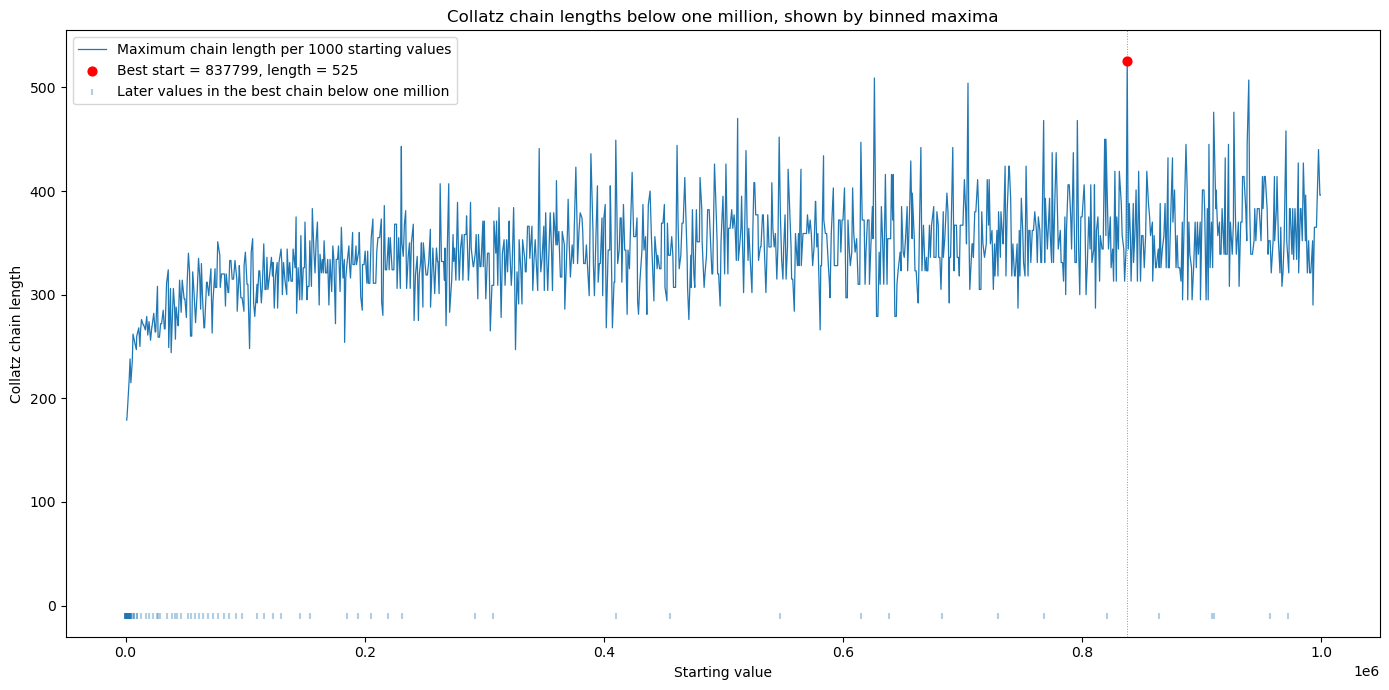

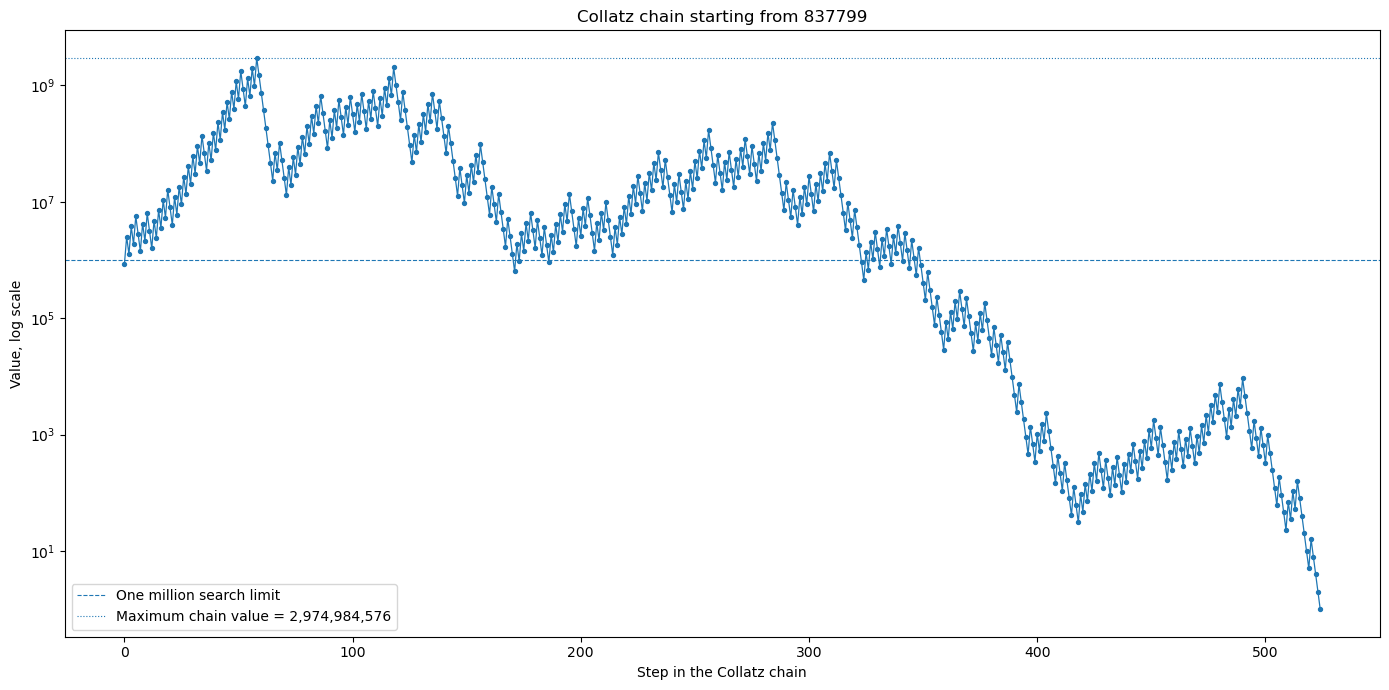

(837799, 525, 2974984576)

In [16]:
import matplotlib.pyplot as plt

limit = 1_000_000
knownLengths = {1: 1}

starts = list(range(1, limit))
lengths = []

bestStart = 1
bestLength = 1

for start in starts:
    length = collatzLength(start, knownLengths)
    lengths.append(length)

    if length > bestLength:
        bestStart = start
        bestLength = length


bestChain = [bestStart]
currentNum = bestStart

while currentNum != 1:
    currentNum = referTo(currentNum)
    bestChain.append(currentNum)


binSize = 1_000

binStarts = []
binMaxLengths = []

for left in range(1, limit, binSize):
    right = min(left + binSize, limit)

    window = lengths[left - 1:right - 1]
    windowStarts = starts[left - 1:right - 1]

    maxLength = max(window)
    maxIndex = window.index(maxLength)

    binStarts.append(windowStarts[maxIndex])
    binMaxLengths.append(maxLength)


chainValuesBelowLimit = sorted({
    value for value in bestChain[1:]
    if value < limit
})


plt.figure(figsize=(14, 7))

plt.plot(
    binStarts,
    binMaxLengths,
    linewidth=0.9,
    label=f"Maximum chain length per {binSize} starting values"
)

plt.axvline(
    bestStart,
    color="red",
    linewidth=0.7,
    linestyle=":",
    alpha=0.6,
    zorder=1
)

plt.scatter(
    [bestStart],
    [bestLength],
    color="red",
    s=40,
    zorder=5,
    label=f"Best start = {bestStart}, length = {bestLength}"
)

plt.scatter(
    chainValuesBelowLimit,
    [-10] * len(chainValuesBelowLimit),
    marker="|",
    s=25,
    alpha=0.35,
    label="Later values in the best chain below one million"
)

plt.xlabel("Starting value")
plt.ylabel("Collatz chain length")
plt.title("Collatz chain lengths below one million, shown by binned maxima")
plt.ylim(-30, bestLength + 30)
plt.legend()
plt.tight_layout()
plt.show()

steps = list(range(len(bestChain)))

plt.figure(figsize=(14, 7))

plt.plot(
    steps,
    bestChain,
    linewidth=0.9
)

plt.scatter(
    steps,
    bestChain,
    s=8
)

plt.axhline(
    1_000_000,
    linestyle="--",
    linewidth=0.8,
    label="One million search limit"
)

plt.axhline(
    max(bestChain),
    linestyle=":",
    linewidth=0.8,
    label=f"Maximum chain value = {max(bestChain):,}"
)

plt.yscale("log")

plt.xlabel("Step in the Collatz chain")
plt.ylabel("Value, log scale")
plt.title(f"Collatz chain starting from {bestStart}")
plt.legend()
plt.tight_layout()
plt.show()

bestStart, bestLength, max(bestChain)